## Walmart Recruiting - Store Sales Forecasting — N-BEATS

## 0. Setup

In [1]:
!pip install -q neuralforecast wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.7 which is incompatible.


In [2]:
import time
import numpy as np
import pandas as pd

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

import wandb

WANDB_PROJECT = "walmart-sales-forecasting"
MODEL_NAME = "NBEATS"
wandb.login()

import glob, os
_train_matches = glob.glob("/kaggle/input/**/train.csv*", recursive=True)
DATA_DIR = os.path.dirname(_train_matches[0])
print("DATA_DIR ->", DATA_DIR, "| found:", _train_matches)

HORIZON = 39          
VAL_SIZE = HORIZON   
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sgurj22 (TwoMusketeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


DATA_DIR -> /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting | found: ['/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip']


## 1. Data Cleaning

In [3]:
train_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/train.csv*")[0], parse_dates=["Date"])
test_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/test.csv*")[0], parse_dates=["Date"])
stores = pd.read_csv(glob.glob(f"{DATA_DIR}/stores.csv*")[0])
features = pd.read_csv(glob.glob(f"{DATA_DIR}/features.csv*")[0], parse_dates=["Date"])

def merge_sources(df):
    feat = features.drop(columns=["IsHoliday"])  # features.csv-ს დუბლირებული IsHoliday აქვს
    return df.merge(stores, on="Store", how="left").merge(feat, on=["Store", "Date"], how="left")

def clean_data(df, is_train=True):
    df = df.copy()
    n_before = len(df)
    df = df.drop_duplicates()

    markdown_cols = [c for c in df.columns if c.startswith("MarkDown")]
    markdown_na = int(df[markdown_cols].isna().sum().sum())
    df[markdown_cols] = df[markdown_cols].fillna(0).clip(lower=0)

    df = df.sort_values(["Store", "Date"])
    for col in ["CPI", "Unemployment"]:
        df[col] = df.groupby("Store")[col].ffill().bfill()

    neg_count = 0
    if is_train:
        neg_count = int((df["Weekly_Sales"] < 0).sum())
        df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)

    df["IsHoliday"] = df["IsHoliday"].astype(bool)
    df["Store"] = df["Store"].astype(int)
    df["Dept"] = df["Dept"].astype(int)

    stats = {"rows_before": n_before, "rows_after": len(df),
              "duplicates_removed": n_before - len(df),
              "negative_sales_clipped": neg_count, "markdown_na_filled": markdown_na}
    return df, stats

train_clean, train_stats = clean_data(merge_sources(train_raw), is_train=True)
test_clean, test_stats = clean_data(merge_sources(test_raw), is_train=False)
print("train:", train_clean.shape, train_stats)
print("test:", test_clean.shape, test_stats)

train: (421570, 16) {'rows_before': 421570, 'rows_after': 421570, 'duplicates_removed': 0, 'negative_sales_clipped': 1285, 'markdown_na_filled': 1422431}
test: (115064, 15) {'rows_before': 115064, 'rows_after': 115064, 'duplicates_removed': 0, 'negative_sales_clipped': 0, 'markdown_na_filled': 51493}


In [4]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="cleaning", name=f"{MODEL_NAME}_Cleaning")
wandb.config.update({f"train_{k}": v for k, v in train_stats.items()})
wandb.config.update({f"test_{k}": v for k, v in test_stats.items()})
wandb.log({"train_missing_after_clean": int(train_clean.isna().sum().sum()),
           "test_missing_after_clean": int(test_clean.isna().sum().sum())})
run.finish()

test_missing_after_clean,▁
train_missing_after_clean,▁
test_missing_after_clean,0
train_missing_after_clean,0


## 2. Feature Engineering

In [5]:
def engineer_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

    superbowl = pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"])
    labor_day = pd.to_datetime(["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"])
    thanksgiving = pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"])
    christmas = pd.to_datetime(["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"])
    df["IsSuperBowl"] = df["Date"].isin(superbowl)
    df["IsLaborDay"] = df["Date"].isin(labor_day)
    df["IsThanksgiving"] = df["Date"].isin(thanksgiving)
    df["IsChristmas"] = df["Date"].isin(christmas)

    df["unique_id"] = df["Store"].astype(str) + "_" + df["Dept"].astype(str)
    df["ds"] = df["Date"]
    return df

train_fe = engineer_features(train_clean)
train_fe["y"] = train_fe["Weekly_Sales"]
test_fe = engineer_features(test_clean)
print(train_fe.shape, "| unique series:", train_fe["unique_id"].nunique())

(421570, 26) | unique series: 3331


In [6]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_engineering", name=f"{MODEL_NAME}_FeatureEngineering")
wandb.log({"n_unique_series": train_fe["unique_id"].nunique(), "n_rows_train": len(train_fe)})
run.finish()

n_rows_train,▁
n_unique_series,▁
n_rows_train,421570
n_unique_series,3331


## 3. Feature Selection

In [7]:
candidate_exog = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
                   "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

corr = train_fe[candidate_exog + ["y"]].corr()["y"].drop("y").abs()
missing_rate = train_fe[candidate_exog].isna().mean()
selection_table = pd.DataFrame({"abs_corr_with_y": corr, "missing_rate": missing_rate}) \
    .sort_values("abs_corr_with_y", ascending=False)

CORR_THRESHOLD, MISSING_THRESHOLD = 0.02, 0.5
selected = selection_table[(selection_table["abs_corr_with_y"] >= CORR_THRESHOLD) &
                            (selection_table["missing_rate"] < MISSING_THRESHOLD)].index.tolist()

print("selection-ის კრიტერიუმებს აკმაყოფილებს:", selected)
print("შენიშვნა: ეს ცვლადები არ მიეწოდება NBEATS-ს -- საბაზისო NBEATS-ს "
      "hist_exog_list/futr_exog_list არგუმენტები საერთოდ არ გააჩნია.")
selection_table

selection-ის კრიტერიუმებს აკმაყოფილებს: ['MarkDown5', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'Unemployment', 'CPI', 'MarkDown2']
შენიშვნა: ეს ცვლადები არ მიეწოდება NBEATS-ს -- საბაზისო NBEATS-ს hist_exog_list/futr_exog_list არგუმენტები საერთოდ არ გააჩნია.


,abs_corr_with_y,missing_rate
MarkDown5,0.050465,0.0
MarkDown1,0.047172,0.0
MarkDown3,0.038562,0.0
MarkDown4,0.037467,0.0
Unemployment,0.025860,0.0
CPI,0.020923,0.0
MarkDown2,0.020720,0.0
Temperature,0.002312,0.0
Fuel_Price,0.000121,0.0


In [8]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_selection", name=f"{MODEL_NAME}_FeatureSelection")
wandb.config.update({"corr_threshold": CORR_THRESHOLD, "missing_threshold": MISSING_THRESHOLD,
                      "selected_but_unused_by_model": ",".join(selected)})
run.finish()

## 4. Train / Validation Split + WMAE

In [9]:
nf_cols = ["unique_id", "ds", "y", "IsHoliday"]  # IsHoliday მხოლოდ WMAE-ის წონისთვის, არა model input
nf_df = train_fe[nf_cols].dropna(subset=["y"]).sort_values(["unique_id", "ds"]).reset_index(drop=True)

cutoff_date = nf_df["ds"].max() - pd.Timedelta(weeks=HORIZON)
Y_train = nf_df[nf_df["ds"] <= cutoff_date].copy()
Y_valid = nf_df[nf_df["ds"] > cutoff_date].copy()

counts = Y_train.groupby("unique_id").size()
valid_ids = (set(Y_valid["unique_id"]) & set(Y_train["unique_id"]))
valid_ids = [uid for uid in valid_ids if counts.get(uid, 0) >= 2 * HORIZON]
Y_train = Y_train[Y_train["unique_id"].isin(valid_ids)].reset_index(drop=True)
Y_valid = Y_valid[Y_valid["unique_id"].isin(valid_ids)].reset_index(drop=True)
nf_df = nf_df[nf_df["unique_id"].isin(valid_ids)].reset_index(drop=True)
print(f"cutoff={cutoff_date.date()} | series={len(valid_ids)} | train rows={len(Y_train)} | valid rows={len(Y_valid)}")

def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return float(np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w))

cutoff=2012-01-27 | series=2858 | train rows=295395 | valid rows=110413


## 5. Hyperparameter Search — Stage 1 (Random Search)


In [10]:
HP_SEARCH_SAMPLE_N = 150

inner_cutoff = cutoff_date - pd.Timedelta(weeks=HORIZON)
Y_train_inner = Y_train[Y_train["ds"] <= inner_cutoff].reset_index(drop=True)
Y_valid_inner = Y_train[Y_train["ds"] > inner_cutoff].reset_index(drop=True)

rng_ids = np.random.RandomState(RANDOM_SEED)
sample_ids = rng_ids.choice(sorted(valid_ids), size=min(HP_SEARCH_SAMPLE_N, len(valid_ids)), replace=False)
Y_train_sample = Y_train_inner[Y_train_inner["unique_id"].isin(sample_ids)].reset_index(drop=True)
Y_valid_sample = Y_valid_inner[Y_valid_inner["unique_id"].isin(sample_ids)].reset_index(drop=True)
print("HP-search series:", len(sample_ids), "| inner cutoff:", inner_cutoff.date())

import random

search_space = {
    "input_size": [HORIZON, 2 * HORIZON, 3 * HORIZON],
    "stack_arch": ["interpretable", "generic"],  # trend+seasonality vs. identity stacks
    "learning_rate": [1e-3, 5e-4, 3e-3],
    "batch_size": [16, 32],
}
rng = random.Random(RANDOM_SEED)
N_TRIALS = 10
configs = []
seen = set()
while len(configs) < N_TRIALS:
    cfg = {k: rng.choice(v) for k, v in search_space.items()}
    key = tuple(sorted(cfg.items()))
    if key not in seen:
        seen.add(key)
        configs.append(cfg)
print(f"{len(configs)} random configs to test -- no wall-clock cap, early_stop_patience_steps "
      f"(+max_steps=100_000 as the formal ceiling) controls training length.")

HP-search series: 150 | inner cutoff: 2011-04-29
10 random configs to test -- no wall-clock cap, early_stop_patience_steps (+max_steps=100_000 as the formal ceiling) controls training length.


In [11]:
def build_nbeats(cfg, h):
    if cfg["stack_arch"] == "interpretable":
        stack_types, n_blocks, mlp_units = ["trend", "seasonality"], [3, 3], [[256, 256]] * 2
    else:
        stack_types, n_blocks, mlp_units = ["identity", "identity"], [3, 3], [[512, 512]] * 2
    return NBEATS(
        h=h, input_size=cfg["input_size"], stack_types=stack_types,
        n_blocks=n_blocks, mlp_units=mlp_units,
        n_harmonics=2, n_polynomials=2,
        loss=MAE(), learning_rate=cfg["learning_rate"],
        batch_size=cfg["batch_size"], windows_batch_size=cfg["batch_size"] * 8,
        max_steps=100_000,
        early_stop_patience_steps=5, val_check_steps=50,
        start_padding_enabled=True,
        scaler_type="standard", random_seed=RANDOM_SEED,
        enable_progress_bar=False,
        accelerator="auto", devices=1,
    )

def evaluate(nf, valid_df):
    preds = nf.predict()
    model_col = [c for c in preds.columns if c not in ("unique_id", "ds")][0]
    merged = preds.merge(valid_df[["unique_id", "ds", "y", "IsHoliday"]], on=["unique_id", "ds"], how="inner")
    score = wmae(merged["y"], merged[model_col], merged["IsHoliday"])
    mae = float(np.mean(np.abs(merged["y"] - merged[model_col])))
    return score, mae

In [12]:
results = []
for i, cfg in enumerate(configs):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search",
                      name=f"{MODEL_NAME}_HPSearch_{trial_label}", config=cfg, reinit=True)

    model = build_nbeats(cfg, h=HORIZON)
    nf = NeuralForecast(models=[model], freq="W-FRI")
    nf.fit(df=Y_train_sample, val_size=VAL_SIZE)  

    elapsed_min = (time.time() - t0) / 60
    try:
        score, mae = evaluate(nf, Y_valid_sample)
    except Exception as e:
        print("eval failed:", repr(e))
        score, mae = np.inf, np.inf

    wandb.log({"val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    run.finish()
    results.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | {elapsed_min:.1f} min")

results_df = pd.DataFrame(results).sort_values("val_WMAE")
n_failed = int(np.isinf(results_df["val_WMAE"]).sum())
if n_failed:
    print(f"WARNING: {n_failed}/{len(results_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row = results_df.iloc[0]
best_cfg = {k: (best_row[k].item() if hasattr(best_row[k], "item") else best_row[k]) for k in search_space}
print("\nStage 1 საუკეთესო კონფიგურაცია:", best_row["trial"], dict(best_cfg))
results_df


=== NBEATS_HPSearch_trial0 {'input_size': 117, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 32} ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 1.1 M  | train
--------------------------------------------------------------
1.1 M     Trainable params
37.0 K    Non-trainable params
1.1 M     Total params
4.518     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.48918
val_MAE,5438.53112
val_WMAE,5850.36039


WMAE=5850.36 | MAE=5438.53 | 0.5 min

=== NBEATS_HPSearch_trial1 {'input_size': 39, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 16} ===


...

WMAE=5043.03 | MAE=4479.37 | 0.2 min

=== NBEATS_HPSearch_trial9 {'input_size': 78, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.8 M  | train
--------------------------------------------------------------
3.8 M     Trainable params
0         Non-trainable params
3.8 M     Total params
15.019    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.18022
val_MAE,3782.93491
val_WMAE,4540.51641


WMAE=4540.52 | MAE=3782.93 | 0.2 min

Stage 1 საუკეთესო კონფიგურაცია: trial5 {'input_size': 117, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 16}


,input_size,stack_arch,learning_rate,batch_size,trial,val_WMAE,val_MAE,train_minutes
5,117,generic,0.0010,16,trial5,4498.037321,3815.869128,0.230507
9,78,generic,0.0010,32,trial9,4540.516410,3782.934908,0.180218
6,117,generic,0.0005,32,trial6,4857.728999,4255.037643,0.212793
4,117,generic,0.0010,32,trial4,4957.043788,4258.090215,0.181834
8,39,generic,0.0010,32,trial8,5043.032151,4479.371681,0.175395
2,117,interpretable,0.0030,32,trial2,5317.268215,4985.840618,0.246111
7,39,interpretable,0.0005,16,trial7,5461.178414,5179.160523,0.241326
0,117,interpretable,0.0010,32,trial0,5850.360390,5438.531115,0.489176
1,39,interpretable,0.0010,16,trial1,5995.071688,5800.370943,0.189285
3,39,interpretable,0.0030,16,trial3,6916.944016,7147.034602,0.185816


## 5b. Hyperparameter Search — Stage 2 (Full Factorial Grid Search)

In [13]:
import itertools

search_space_2 = {
    "input_size": [26, 39, 52],           
    "stack_arch": ["interpretable", "generic"],
    "learning_rate": [1e-3, 2e-3, 4e-3],  
    "batch_size": [16, 32],
}

keys, values = zip(*search_space_2.items())
configs_2 = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
print(f"{len(configs_2)} grid configs to test (Stage 2 -- full factorial, "
      f"input_size dominance already established in Stage 1).")

36 grid configs to test (Stage 2 -- full factorial, input_size dominance already established in Stage 1).


In [14]:
results_2 = []
for i, cfg in enumerate(configs_2):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch2_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search_2",
                      name=f"{MODEL_NAME}_HPSearch2_{trial_label}", config=cfg, reinit=True)

    model = build_nbeats(cfg, h=HORIZON)
    nf = NeuralForecast(models=[model], freq="W-FRI")
    nf.fit(df=Y_train_sample, val_size=VAL_SIZE)

    elapsed_min = (time.time() - t0) / 60
    try:
        score, mae = evaluate(nf, Y_valid_sample)
    except Exception as e:
        print("eval failed:", repr(e))
        score, mae = np.inf, np.inf

    wandb.log({"val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    run.finish()
    results_2.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | {elapsed_min:.1f} min")

results_2_df = pd.DataFrame(results_2).sort_values("val_WMAE")
n_failed_2 = int(np.isinf(results_2_df["val_WMAE"]).sum())
if n_failed_2:
    print(f"WARNING: {n_failed_2}/{len(results_2_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row_2 = results_2_df.iloc[0]
best_cfg_2 = {k: (best_row_2[k].item() if hasattr(best_row_2[k], "item") else best_row_2[k]) for k in search_space_2}
print("\nStage 2 საუკეთესო კონფიგურაცია:", best_row_2["trial"], dict(best_cfg_2))
results_2_df


=== NBEATS_HPSearch2_trial0 {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 16} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.24117
val_MAE,4482.6851
val_WMAE,5008.35616


WMAE=5008.36 | MAE=4482.69 | 0.2 min

=== NBEATS_HPSearch2_trial1 {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

...

WMAE=5062.25 | MAE=4572.93 | 0.3 min

=== NBEATS_HPSearch2_trial35 {'input_size': 52, 'stack_arch': 'generic', 'learning_rate': 0.004, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.6 M  | train
--------------------------------------------------------------
3.6 M     Trainable params
0         Non-trainable params
3.6 M     Total params
14.379    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.23701
val_MAE,4842.57584
val_WMAE,5600.52568


WMAE=5600.53 | MAE=4842.58 | 0.2 min

Stage 2 საუკეთესო კონფიგურაცია: trial3 {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.002, 'batch_size': 32}


,input_size,stack_arch,learning_rate,batch_size,trial,val_WMAE,val_MAE,train_minutes
3,26,interpretable,0.002,32,trial3,4310.395636,3804.052008,0.187349
2,26,interpretable,0.002,16,trial2,4496.666058,4078.792820,0.227767
31,52,generic,0.001,32,trial31,4502.459773,3812.423682,0.179328
33,52,generic,0.002,32,trial33,4547.213105,4064.200448,0.214140
18,39,generic,0.001,16,trial18,4577.937835,4066.800623,0.192431
0,26,interpretable,0.001,16,trial0,5008.356158,4482.685101,0.241172
19,39,generic,0.001,32,trial19,5043.032151,4479.371681,0.176607
34,52,generic,0.004,16,trial34,5062.247539,4572.926327,0.252731
8,26,generic,0.002,16,trial8,5136.446687,4602.451880,0.183182
30,52,generic,0.001,16,trial30,5164.396407,4491.175219,0.242638


In [15]:
if best_row_2["val_WMAE"] < best_row["val_WMAE"]:
    winning_stage = "stage_2 (full grid)"
    best_cfg = best_cfg_2
    best_val_wmae = float(best_row_2["val_WMAE"])
else:
    winning_stage = "stage_1 (random search)"
    best_val_wmae = float(best_row["val_WMAE"])

print(f"გამარჯვებული: {winning_stage}")
print(f"საბოლოო best_cfg: {best_cfg}")
print(f"საბოლოო HP-search val_WMAE (150-series sample): {best_val_wmae:.2f}")
print(f"შედარებისთვის -- stage1 best: {best_row['val_WMAE']:.2f} | stage2 best: {best_row_2['val_WMAE']:.2f}")

გამარჯვებული: stage_2 (full grid)
საბოლოო best_cfg: {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.002, 'batch_size': 32}
საბოლოო HP-search val_WMAE (150-series sample): 4310.40
შედარებისთვის -- stage1 best: 4498.04 | stage2 best: 4310.40


## 6. Final Training

In [16]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="final",
                  name=f"{MODEL_NAME}_Final_Training",
                  config=dict(best_cfg))
wandb.config.update({"winning_hp_search_stage": winning_stage})

t0 = time.time()
final_model = build_nbeats(best_cfg, h=HORIZON)
nf_final = NeuralForecast(models=[final_model], freq="W-FRI")
nf_final.fit(df=Y_train, val_size=VAL_SIZE)
elapsed_min = (time.time() - t0) / 60

Y_valid_full = train_fe.loc[train_fe["ds"] > cutoff_date, ["unique_id", "ds", "y", "IsHoliday"]].dropna(subset=["y"]).copy()
_pre = train_fe.loc[train_fe["ds"] <= cutoff_date].dropna(subset=["y"])
_uid_mean = _pre.groupby("unique_id")["y"].mean()
_store_mean = _pre.groupby(_pre["unique_id"].str.split("_").str[0])["y"].mean()
_global_mean = float(_pre["y"].mean())

preds_full = nf_final.predict()
model_col = [c for c in preds_full.columns if c not in ("unique_id", "ds")][0]
merged_full = Y_valid_full.merge(preds_full[["unique_id", "ds", model_col]], on=["unique_id", "ds"], how="left")
_miss = merged_full[model_col].isna()
_fb = merged_full.loc[_miss, "unique_id"].map(_uid_mean)
_fb = _fb.fillna(merged_full.loc[_miss, "unique_id"].str.split("_").str[0].map(_store_mean)).fillna(_global_mean)
merged_full.loc[_miss, model_col] = _fb
final_wmae = wmae(merged_full["y"], merged_full[model_col], merged_full["IsHoliday"])
final_mae = float(np.mean(np.abs(merged_full["y"] - merged_full[model_col])))
print(f"full-population eval: {merged_full['unique_id'].nunique()} series | "
      f"fallback rows: {int(_miss.sum())}/{len(merged_full)}")

wandb.log({"val_WMAE": final_wmae, "val_MAE": final_mae, "train_minutes": elapsed_min,
           "n_fallback_rows": int(_miss.sum()), "n_eval_rows": len(merged_full)})
wandb.config.update({"n_series_used": len(valid_ids), "eval_population": "full_with_fallback"})
run.finish()

print(f"NBEATS final WMAE={final_wmae:.2f} | MAE={final_mae:.2f} | {elapsed_min:.1f} min")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

full-population eval: 3204 series | fallback rows: 5203/115588


/tmp/ipykernel_58/270888561.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[523.66733333  23.70153846 523.66733333 ...  62.07909091  15.07809524
  59.02043478]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  merged_full.loc[_miss, model_col] = _fb


n_eval_rows,▁
n_fallback_rows,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_eval_rows,115588
n_fallback_rows,5203
train_minutes,0.16597
val_MAE,2481.63771
val_WMAE,2501.49028


NBEATS final WMAE=2501.49 | MAE=2481.64 | 0.2 min


## 7. Pipeline + Model Registry

In [17]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="deploy_refit",
                  name=f"{MODEL_NAME}_Deploy_Refit",
                  config=dict(best_cfg))

t0 = time.time()
deploy_model = build_nbeats(best_cfg, h=HORIZON)
nf_deploy = NeuralForecast(models=[deploy_model], freq="W-FRI")
nf_deploy.fit(df=nf_df, val_size=VAL_SIZE)
elapsed_min = (time.time() - t0) / 60

wandb.log({"train_minutes": elapsed_min})
wandb.config.update({"deploy_max_train_date": str(nf_df["ds"].max().date())})

PIPELINE_DIR = "./nbeats_pipeline_model"  
nf_deploy.save(path=PIPELINE_DIR, overwrite=True)
run.finish()
print(f"Deploy refit done ({elapsed_min:.1f} min), max train date={nf_df['ds'].max().date()}")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
train_minutes,0.22531


Deploy refit done (0.2 min), max train date=2012-10-26


In [18]:
class NBEATSPipeline:

    def __init__(self, nf, history_df):
        self.nf = nf
        self._dept_mean = history_df.groupby(["Store", "Dept"])["y"].mean()
        self._store_mean = history_df.groupby("Store")["y"].mean()
        self._global_mean = float(history_df["y"].mean())

    def _fallback_value(self, store, dept):
        key = (store, dept)
        if key in self._dept_mean.index:
            return float(self._dept_mean[key])
        if store in self._store_mean.index:
            return float(self._store_mean[store])
        return self._global_mean

    def predict(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        df = raw_df.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df, _ = clean_data(merge_sources(df), is_train=False)
        df = engineer_features(df)

        preds = self.nf.predict()
        model_col = [c for c in preds.columns if c not in ("unique_id", "ds")][0]
        out = df[["unique_id", "ds", "Store", "Dept"]].merge(preds, on=["unique_id", "ds"], how="left")
        out = out.rename(columns={model_col: "Weekly_Sales_Pred"})

        missing = out["Weekly_Sales_Pred"].isna()
        n_missing = int(missing.sum())
        if n_missing:
            out.loc[missing, "Weekly_Sales_Pred"] = out.loc[missing].apply(
                lambda r: self._fallback_value(r["Store"], r["Dept"]), axis=1
            )
            print(f"NBEATSPipeline: filled {n_missing}/{len(out)} rows "
                  f"({n_missing / len(out):.1%}) via Store/Dept fallback mean "
                  f"(series not seen by NBEATS due to valid_ids history filter).")

        return out.drop(columns=["Store", "Dept"])


pipeline = NBEATSPipeline(nf_deploy, history_df=train_fe)
preds_preview = pipeline.predict(test_raw)  
print(preds_preview.shape)
preds_preview.head()

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


NBEATSPipeline: filled 4963/115064 rows (4.3%) via Store/Dept fallback mean (series not seen by NBEATS due to valid_ids history filter).
(115064, 3)


/tmp/ipykernel_58/546341028.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[306.09108108 306.09108108 306.09108108 ...  46.14646154  15.0936
  46.14646154]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[missing, "Weekly_Sales_Pred"] = out.loc[missing].apply(


,unique_id,ds,Weekly_Sales_Pred
0,1_1,2012-11-02,24408.177734
1,1_2,2012-11-02,47364.496094
2,1_3,2012-11-02,9419.085938
3,1_4,2012-11-02,40123.558594
4,1_5,2012-11-02,23235.212891


In [19]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="registry",
                  name=f"{MODEL_NAME}_Pipeline_Registry")

artifact = wandb.Artifact(name=f"{MODEL_NAME}_pipeline", type="model", metadata=dict(best_cfg))
artifact.add_dir(PIPELINE_DIR)
run.log_artifact(artifact)
run.link_artifact(artifact, target_path=f"wandb-registry-model/{MODEL_NAME}")
run.finish()
print(f"'{MODEL_NAME}_pipeline' დარეგისტრირდა Wandb Registry-ში.")

wandb: Adding directory to artifact (nbeats_pipeline_model)... Done. 0.0s


'NBEATS_pipeline' დარეგისტრირდა Wandb Registry-ში.


## 8. შედეგების ვიზუალიზაცია

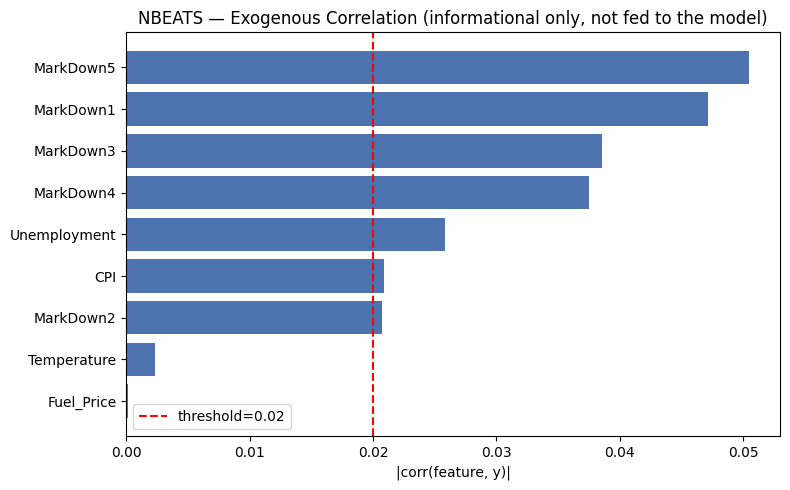

In [20]:
import matplotlib.pyplot as plt

FIGURES_DIR = "./nbeats_figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

viz_run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                      name=f"{MODEL_NAME}_Figures")

sel_sorted = selection_table.sort_values("abs_corr_with_y")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sel_sorted.index, sel_sorted["abs_corr_with_y"], color="#4C72B0")
ax.axvline(CORR_THRESHOLD, color="red", linestyle="--", label=f"threshold={CORR_THRESHOLD}")
ax.set_xlabel("|corr(feature, y)|")
ax.set_title("NBEATS — Exogenous Correlation (informational only, not fed to the model)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_feature_selection.png", dpi=150)
wandb.log({"feature_selection": wandb.Image(fig)})
plt.show()

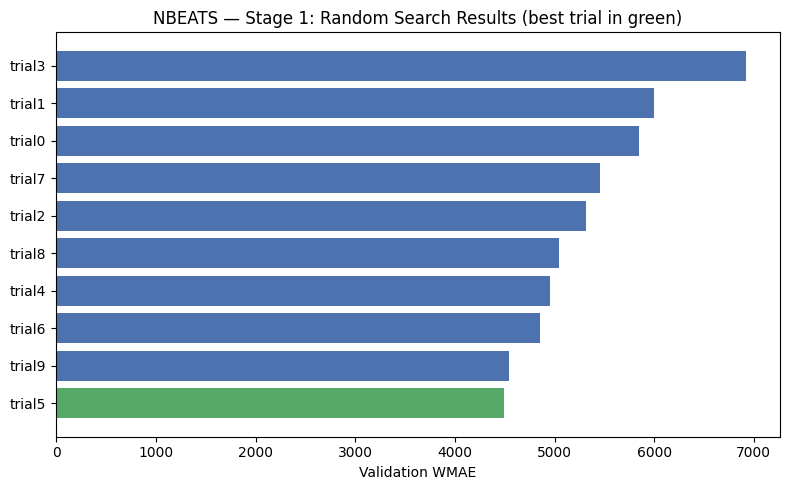

In [21]:
plot_df = results_df.sort_values("val_WMAE")
colors = ["#55A868" if t == best_row["trial"] else "#4C72B0" for t in plot_df["trial"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["trial"], plot_df["val_WMAE"], color=colors)
ax.set_xlabel("Validation WMAE")
ax.set_title("NBEATS — Stage 1: Random Search Results (best trial in green)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_hp_search1_results.png", dpi=150)
wandb.log({"hp_search_stage1": wandb.Image(fig), "hp_search_stage1_table": wandb.Table(dataframe=results_df)})
plt.show()

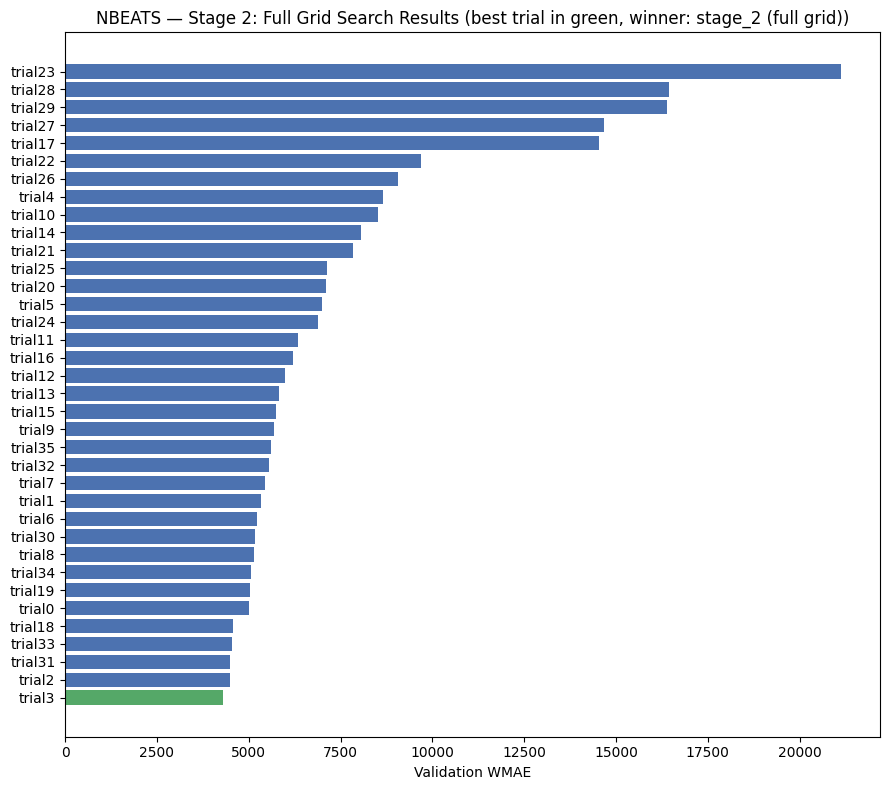

In [22]:
plot_df2 = results_2_df.sort_values("val_WMAE")
colors2 = ["#55A868" if t == best_row_2["trial"] else "#4C72B0" for t in plot_df2["trial"]]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df2["trial"], plot_df2["val_WMAE"], color=colors2)
ax.set_xlabel("Validation WMAE")
ax.set_title(f"NBEATS — Stage 2: Full Grid Search Results (best trial in green, winner: {winning_stage})")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_hp_search2_results.png", dpi=150)
wandb.log({"hp_search_stage2": wandb.Image(fig), "cv_comparison": wandb.Image(fig),
           "hp_search_stage2_table": wandb.Table(dataframe=results_2_df)})
plt.show()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


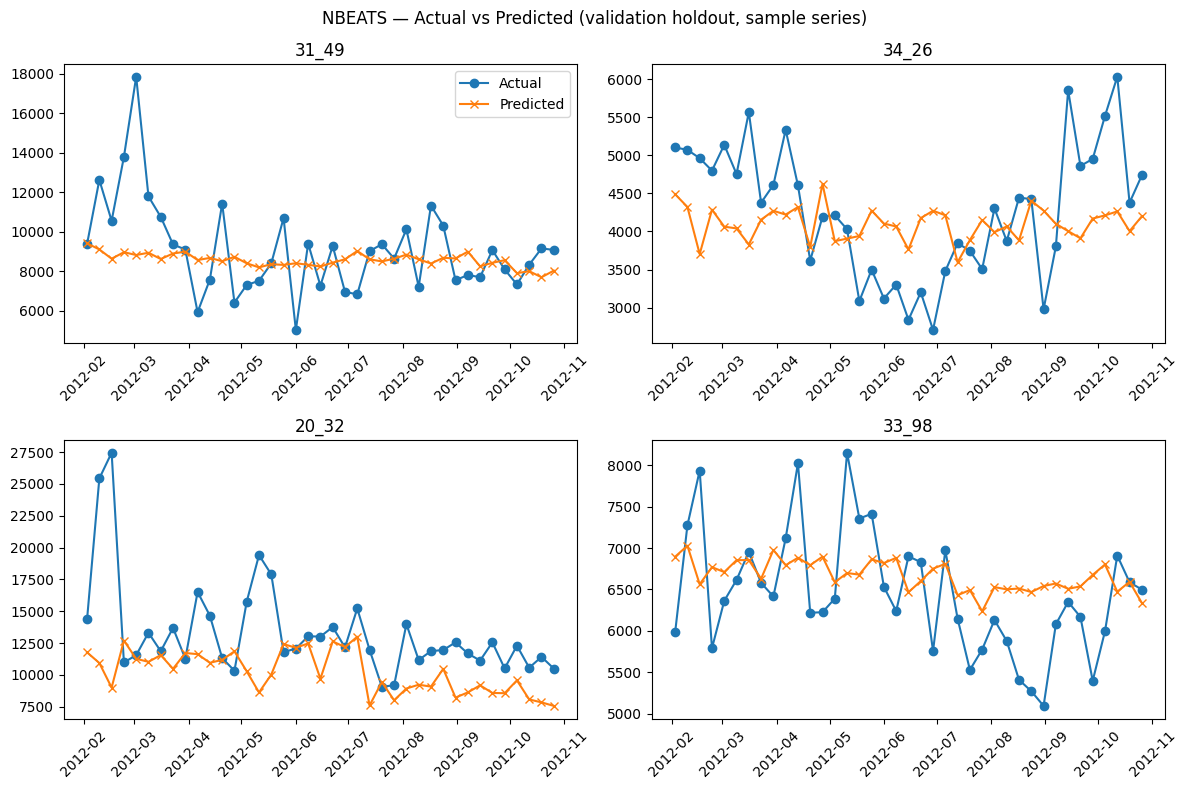

In [23]:
preds_valid = nf_final.predict() 
model_col = [c for c in preds_valid.columns if c not in ("unique_id", "ds")][0]
merged_valid = preds_valid.merge(Y_valid[["unique_id", "ds", "y"]], on=["unique_id", "ds"], how="inner")

sample_uids = merged_valid["unique_id"].drop_duplicates().sample(4, random_state=RANDOM_SEED).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, uid in zip(axes.flat, sample_uids):
    sub = merged_valid[merged_valid["unique_id"] == uid].sort_values("ds")
    ax.plot(sub["ds"], sub["y"], label="Actual", marker="o")
    ax.plot(sub["ds"], sub[model_col], label="Predicted", marker="x")
    ax.set_title(uid)
    ax.tick_params(axis="x", rotation=45)
axes.flat[0].legend()
fig.suptitle("NBEATS — Actual vs Predicted (validation holdout, sample series)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_actual_vs_predicted.png", dpi=150)
wandb.log({"actual_vs_predicted": wandb.Image(fig)})
plt.show()

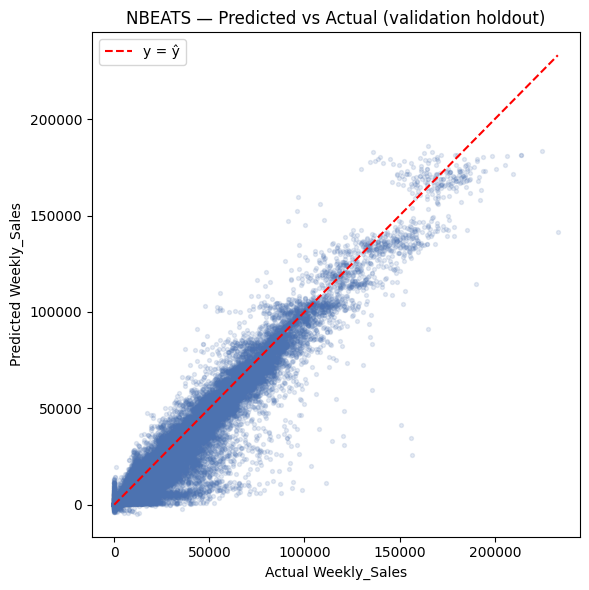

Figures saved to: /kaggle/working/nbeats_figures and logged to Wandb run: NBEATS_Figures


In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged_valid["y"], merged_valid[model_col], alpha=0.15, s=8, color="#4C72B0")
lims = [0, max(merged_valid["y"].max(), merged_valid[model_col].max())]
ax.plot(lims, lims, color="red", linestyle="--", label="y = ŷ")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Predicted Weekly_Sales")
ax.set_title("NBEATS — Predicted vs Actual (validation holdout)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_pred_vs_actual_scatter.png", dpi=150)
wandb.log({"pred_vs_actual_scatter": wandb.Image(fig), "holdout_diagnostics": wandb.Image(fig)})
plt.show()

viz_run.finish()
print("Figures saved to:", os.path.abspath(FIGURES_DIR), "and logged to Wandb run:", f"{MODEL_NAME}_Figures")

## 9. Full Results Summary


In [25]:
import contextlib, io

def print_summary():
    print("=" * 70)
    print(f"{MODEL_NAME} — FULL RESULTS SUMMARY")
    print("=" * 70)

    print("\n--- 1. Data Cleaning ---")
    for k, v in train_stats.items():
        print(f"  train_{k}: {v}")
    for k, v in test_stats.items():
        print(f"  test_{k}: {v}")

    print("\n--- 2. Feature Engineering ---")
    print(f"  n_rows_train: {len(train_fe)}")
    print(f"  n_unique_series: {train_fe['unique_id'].nunique()}")

    print("\n--- 3. Feature Selection (informational, not fed to model) ---")
    print(selection_table.to_string())
    print(f"  selected (corr>={CORR_THRESHOLD}, missing<{MISSING_THRESHOLD}): {selected}")

    print("\n--- 4. Train/Valid Split ---")
    print(f"  cutoff_date: {cutoff_date.date()}")
    print(f"  n_series (valid_ids): {len(valid_ids)}")
    print(f"  train rows: {len(Y_train)} | valid rows: {len(Y_valid)}")

    print("\n--- 5. Hyperparameter Search -- Stage 1 (Random Search, 10 trials) ---")
    print(results_df.to_string(index=False))
    print(f"\n  Stage 1 best: {best_row['trial']} | val_WMAE={best_row['val_WMAE']:.2f} | val_MAE={best_row['val_MAE']:.2f}")

    print("\n--- 5b. Hyperparameter Search -- Stage 2 (Full Grid Search, "
          f"{len(configs_2)} trials) ---")
    print(results_2_df.to_string(index=False))
    print(f"\n  Stage 2 best: {best_row_2['trial']} | val_WMAE={best_row_2['val_WMAE']:.2f} | val_MAE={best_row_2['val_MAE']:.2f}")

    print(f"\n  WINNING STAGE: {winning_stage}")
    print(f"  FINAL best_cfg: {best_cfg}")

    print("\n--- 6. Final Training (best_cfg, full Y_train) ---")
    print(f"  final_wmae (holdout, 39-week): {final_wmae:.2f}")
    print(f"  final_mae  (holdout, 39-week): {final_mae:.2f}")

    print("\n--- 7. Deploy Refit (best_cfg, full history nf_df) ---")
    print(f"  max train date used: {nf_df['ds'].max().date()}")
    print(f"  pipeline saved to: {PIPELINE_DIR}")

    print("\n--- 8. Pipeline Preview (raw test.csv -> predictions, with fallback) ---")
    print(f"  shape: {preds_preview.shape}")
    print(preds_preview.head(10).to_string(index=False))

    print("\n--- 9. Wandb Registry ---")
    print(f"  artifact name: {MODEL_NAME}_pipeline")
    print(f"  registry target: wandb-registry-model/{MODEL_NAME}")

    print("\n" + "=" * 70)
    print("END OF SUMMARY")
    print("=" * 70)

print_summary()

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    print_summary()
summary_text = buf.getvalue()
with open("./nbeats_results_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print(f"\nSaved to ./nbeats_results_summary.txt ({len(summary_text)} chars)")

NBEATS — FULL RESULTS SUMMARY

--- 1. Data Cleaning ---
  train_rows_before: 421570
  train_rows_after: 421570
  train_duplicates_removed: 0
  train_negative_sales_clipped: 1285
  train_markdown_na_filled: 1422431
  test_rows_before: 115064
  test_rows_after: 115064
  test_duplicates_removed: 0
  test_negative_sales_clipped: 0
  test_markdown_na_filled: 51493

--- 2. Feature Engineering ---
  n_rows_train: 421570
  n_unique_series: 3331

--- 3. Feature Selection (informational, not fed to model) ---
              abs_corr_with_y  missing_rate
MarkDown5            0.050465           0.0
MarkDown1            0.047172           0.0
MarkDown3            0.038562           0.0
MarkDown4            0.037467           0.0
Unemployment         0.025860           0.0
CPI                  0.020923           0.0
MarkDown2            0.020720           0.0
Temperature          0.002312           0.0
Fuel_Price           0.000121           0.0
  selected (corr>=0.02, missing<0.5): ['MarkDown5', 'Ma